In [5]:
import os
import pandas as pd

BASE_DIR = r"C:\Users\AADHYA SHARMA\Downloads\customer-churn-revenue-intelligence"
CLEAN_DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "ecommerce_churn_clean.csv")

df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded Clean Dataset Successfully! Shape: {df.shape[0]} rows, {df.shape} columns")
df.head()

Loaded Clean Dataset Successfully! Shape: 5630 rows, (5630, 20) columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1,1,5,159.93
1,50002,1,9.0,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0,1,0,120.90
2,50003,1,9.0,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0,1,3,120.28
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0,1,3,134.07
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,3.0,3,Mobile Phone,5,Single,3,0,11.0,1,1,3,129.60


Loaded Clean Dataset Successfully. Shape: 5630 rows, (5630, 20) columns

EXECUTIVE BUSINESS HEALTH DASHBOARD
Total Customer Base:         5,630
Active / Retained Customers: 4,682 (83.16%)
Churned Customers:           948 (16.84%)
Total Monetary Proxy Pool:   $997,765.66
Monetary Value at Churn Risk:$152,031.64 (15.24%)


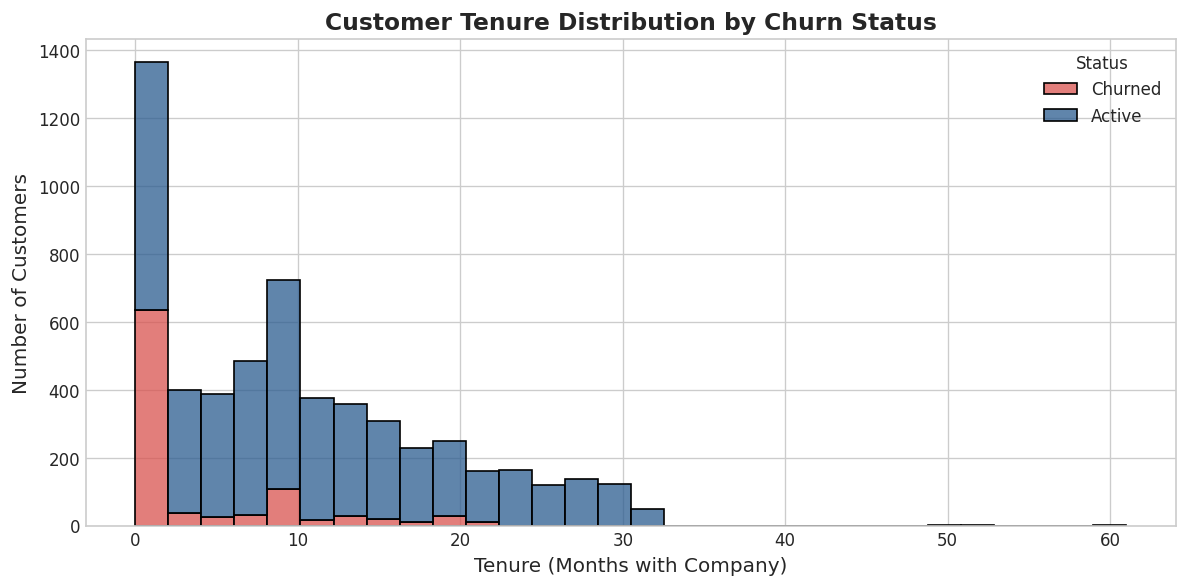

C:\Users\AADHYA SHARMA\AppData\Local\Temp\ipykernel_13960\1906464037.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_churn, x='Category', y='Churn_Rate', palette='Reds_r')


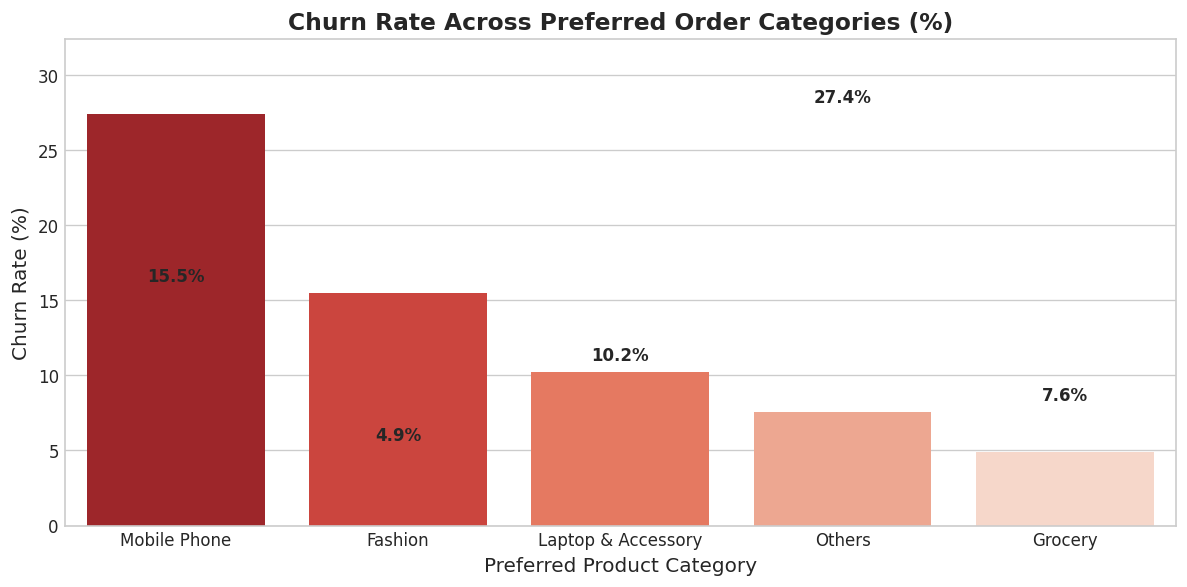

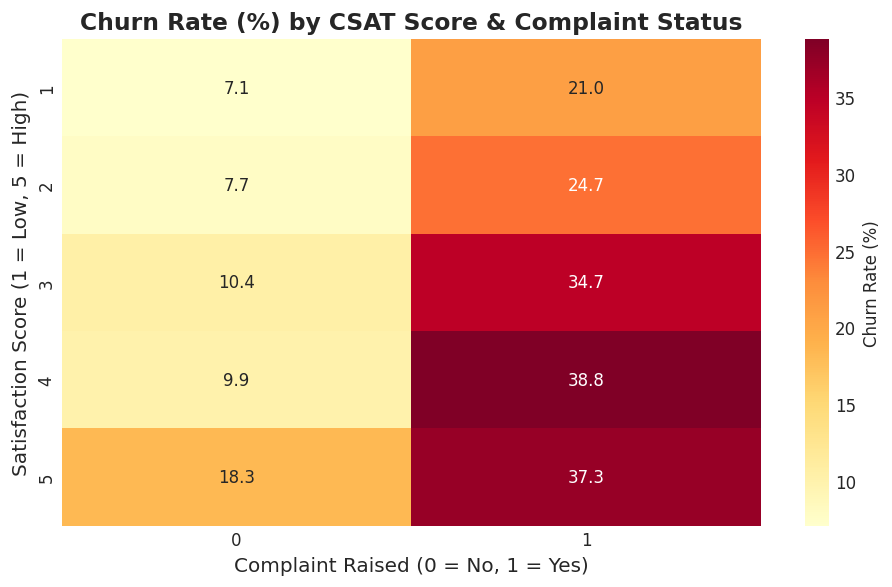

In [4]:
# NOTEBOOK 02: EXPLORATORY DATA ANALYSIS & BUSINESS KPIS

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure base project paths
BASE_DIR = r"C:\Users\AADHYA SHARMA\Downloads\customer-churn-revenue-intelligence"
VISUALIZATIONS_DIR = os.path.join(BASE_DIR, "visualizations")
CLEAN_DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "customer_churn_cleaned.csv")

# Create visualizations folder safely
os.makedirs(VISUALIZATIONS_DIR, exist_ok=True)

# Display configurations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Step 2: Load Clean Data
# Fallback check if saved as ecommerce_churn_clean.csv
if not os.path.exists(CLEAN_DATA_PATH):
    CLEAN_DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "ecommerce_churn_clean.csv")

df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded Clean Dataset Successfully. Shape: {df.shape[0]} rows, {df.shape} columns")

# Step 3: Global Business KPI Calculations
total_customers = len(df)
churned_customers = df['Churn'].sum()
active_customers = total_customers - churned_customers
churn_rate = (churned_customers / total_customers) * 100
retention_rate = 100.0 - churn_rate

total_cashback_pool = df['CashbackAmount'].sum()
churned_cashback_loss = df[df['Churn'] == 1]['CashbackAmount'].sum()
active_cashback_pool = df[df['Churn'] == 0]['CashbackAmount'].sum()

print("\n" + "="*45)
print("EXECUTIVE BUSINESS HEALTH DASHBOARD")
print("="*45)
print(f"Total Customer Base:         {total_customers:,}")
print(f"Active / Retained Customers: {active_customers:,} ({retention_rate:.2f}%)")
print(f"Churned Customers:           {churned_customers:,} ({churn_rate:.2f}%)")
print(f"Total Monetary Proxy Pool:   ${total_cashback_pool:,.2f}")
print(f"Monetary Value at Churn Risk:${churned_cashback_loss:,.2f} ({(churned_cashback_loss/total_cashback_pool)*100:.2f}%)")
print("="*45)

# Step 4: Visual Analysis 1 - Churn Distribution by Customer Lifecycle (Tenure)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack', bins=30, palette={0: '#2b5c8f', 1: '#d9534f'})
plt.title('Customer Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months with Company)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Status', labels=['Churned', 'Active'])
plt.tight_layout()
plt.savefig(os.path.join(VISUALIZATIONS_DIR, "churn_by_tenure.png"), bbox_inches='tight')
plt.show()

# Business Insight: Churn heavily concentrates in early-stage customers (0 to 2 months tenure), indicating high onboarding friction.

# Step 5: Visual Analysis 2 - Churn Rate by Product Category
category_churn = df.groupby('PreferedOrderCat')['Churn'].agg(['count', 'mean']).reset_index()
category_churn.columns = ['Category', 'Total_Customers', 'Churn_Rate']
category_churn['Churn_Rate'] = category_churn['Churn_Rate'] * 100
category_churn = category_churn.sort_values(by='Churn_Rate', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=category_churn, x='Category', y='Churn_Rate', palette='Reds_r')
plt.title('Churn Rate Across Preferred Order Categories (%)', fontsize=14, fontweight='bold')
plt.xlabel('Preferred Product Category', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, max(category_churn['Churn_Rate']) + 5)
for idx, row in category_churn.iterrows():
    plt.text(idx, row['Churn_Rate'] + 0.8, f"{row['Churn_Rate']:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VISUALIZATIONS_DIR, "churn_by_category.png"), bbox_inches='tight')
plt.show()

# Business Insight: Mobile Phone category experiences the highest churn rate (~27%), warranting warranty & device onboarding reviews.

# Step 6: Visual Analysis 3 - Impact of Customer Complaints & Satisfaction Score
complaint_summary = df.groupby(['SatisfactionScore', 'Complain'])['Churn'].mean().unstack() * 100

plt.figure(figsize=(8, 5))
sns.heatmap(complaint_summary, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by CSAT Score & Complaint Status', fontsize=14, fontweight='bold')
plt.xlabel('Complaint Raised (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Satisfaction Score (1 = Low, 5 = High)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VISUALIZATIONS_DIR, "complaint_satisfaction_matrix.png"), bbox_inches='tight')
plt.show()

# Business Insight: Raising a complaint roughly doubles the churn probability across all satisfaction score levels.